# 04 · Feature engineering (Issue #6)

```
01_train_base_eda          (Skylar, EDA only)
02_static_0_preprocessing  (Skylar, EDA only)
        │  findings / rules
        ▼
03_clean_missing_outliers   Issue #3   raw CSV ─► data/interim/applicant_{train,test}.parquet
        ▼
04_feature_engineering      Issue #6   ─► data/processed/features_{train,test}.parquet
        ▼
05_encode_scale             Issue #4   ─► data/processed/model_ready_{fit,valid,test}.parquet
        ▼
models (October)
```
Run 03 → 04 → 05 in order; each notebook reads the file the previous one saved.

**Input:** `data/interim/applicant_{train,test}.parquet` (from 03) plus the history tables in `data/raw`
**Output:** `data/processed/features_{train,test}.parquet`: still **one row per `case_id`**, with raw (unscaled) values.

### How the data is shaped
| table | rows per applicant | what it is |
|---|---|---|
| base + static_0 | 1 | the application itself (already cleaned in 03) |
| static_cb_0 | 0 or 1 | bureau summary; **missing for thin-file applicants** |
| person_1 | 1-2 | applicant (+ co-applicant) |
| credit_bureau_a_1 | 0-8 | past credit contracts; **0 rows = thin-file** |
| credit_bureau_a_2 | 0-n | monthly payment records under each contract |
| applprev_1 | 0-4 | previous applications |
| tax_registry_a_1 | 0-3 | declared tax / income records |

A model needs one row per applicant, so every multi-row table is **aggregated** (count / sum / mean / max) by `case_id`
and then left-joined onto the applicant table. This is the "relational aggregation" step in the technical report (§4, §15).

## Why feature engineering comes before encoding & scaling

```
01 base EDA ─┐
02 static_0 EDA ─┴─► 03 clean ─► 04 feature engineering ─► 05 encode & scale ─► models
```

1. **Features are built from raw values, and encoding would break the math.** `cb_credamount_sum` adds up real contract amounts,
   `credit_to_income` divides real amounts, and `age_years` subtracts real dates. After scaling, a "sum of z-scores" or "ratio of
   z-scores" means nothing. For example, income 22,000 and credit 15,000 give a real ratio of 0.68, but both scale to ≈ 0,
   so their ratio becomes nonsense or divides by zero.
2. **The history tables have many rows per applicant.** They must be aggregated to one row per `case_id` before any model-level
   encoding. Their categories are turned into **counts per applicant** here (e.g. `cb_class_count_*`, `prev_status_count_*`):
   that encoding has to happen during aggregation.
3. **Encode/scale also imputes missing values.** Many new features are missing for someone (e.g. `cb_overdue_mean` for every
   thin-file applicant). Running 05 afterwards means these columns get imputed, get missing-flags, and get scaled.
4. **The encoder/scaler must be fitted once, on the final columns, on training weeks only.** Encoding first would require a second pass.

Only single-value categories (education, marital status, housing type) are left as text here; 05 one-hot encodes them.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent                      # notebooks/ -> repo root
RAW = ROOT / "data" / "raw" / "csv_files"     # unzipped dataset (git-ignored, see README)
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
INTERIM.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

# Train = weeks 0-91, real test = weeks 92-107. Weeks 80-91 are our out-of-time
# validation set, so anything "learned" from data (caps, medians, scalers)
# is fitted on weeks < 80 only.
VALID_START_WEEK = 80

In [2]:
def read_table(split, name):
    """Load a raw table, stacking fragments like train_credit_bureau_a_1_0/_1."""
    folder = RAW / split
    files = sorted(folder.glob(f"{split}_{name}.csv")) + sorted(folder.glob(f"{split}_{name}_[0-9].csv"))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


def ratio(a, b):
    return a / b.replace(0, np.nan)

## 1. Feature builders, one per table

Each function takes a raw table and returns **one row per `case_id`**.

In [3]:
def applicant_features(app):
    """Ratios on the application itself: affordability is more telling than raw amounts."""
    out = app[["case_id"]].copy()
    out["age_years"] = (app["date_decision"] - app["birth_259D"]).dt.days / 365.25
    out["credit_to_income"] = ratio(app["credamount_770A"], app["mainoccupationinc_384A"])
    out["annuity_to_income"] = ratio(app["annuity_780A"], app["mainoccupationinc_384A"])
    out["annuity_to_credit"] = ratio(app["annuity_780A"], app["credamount_770A"])  # ~ 1 / loan term
    return out


def person_features(person):
    g = person.groupby("case_id")
    out = pd.DataFrame({
        "person_count": g.size(),
        "person_income_sum": g["mainoccupationinc_384A"].sum(min_count=1),
        "person_income_max": g["mainoccupationinc_384A"].max(),
        "person_employed_total_mean": g["empl_employedtotal_800L"].mean(),
    })
    applicant = person[person["personindex_1023L"] == 0].set_index("case_id")
    out["housingtype_772M"] = applicant["housingtype_772M"]
    out["has_coapplicant"] = (out["person_count"] > 1).astype(int)
    return out.reset_index()


def bureau_contract_features(cb1):
    cb1 = cb1.assign(overdue_missing=cb1["overdueamountmax_950A"].isna())
    g = cb1.groupby("case_id")
    out = pd.DataFrame({
        "cb_contract_count": g.size(),
        "cb_credamount_sum": g["credamount_770A"].sum(),
        "cb_credamount_mean": g["credamount_770A"].mean(),
        "cb_credamount_max": g["credamount_770A"].max(),
        "cb_overdue_max": g["overdueamountmax_950A"].max(),
        "cb_overdue_mean": g["overdueamountmax_950A"].mean(),
        "cb_overdue_missing_share": g["overdue_missing"].mean(),
        "cb_dpd_mean": g["pmts_dpdvalue_108P"].mean(),
        "cb_dpd_max": g["pmts_dpdvalue_108P"].max(),
    })
    # One count column per contract type (6 masked categories).
    classes = pd.crosstab(cb1["case_id"], cb1["classificationofcontr_13M"]).add_prefix("cb_class_count_")
    return out.join(classes).reset_index()


def bureau_payment_features(cb2):
    overdue = cb2["pmts_overdue_1140A"]
    cb2 = cb2.assign(is_overdue=(overdue > 0).where(overdue.notna()))
    g = cb2.groupby("case_id")
    return pd.DataFrame({
        "pay_record_count": g.size(),
        "pay_overdue_sum": g["pmts_overdue_1140A"].sum(min_count=1),
        "pay_overdue_mean": g["pmts_overdue_1140A"].mean(),
        "pay_overdue_max": g["pmts_overdue_1140A"].max(),
        "pay_overdue_share": g["is_overdue"].mean(),  # share of known payments that were late
    }).reset_index()


def previous_application_features(prev, decision_dates):
    prev = prev.merge(decision_dates, on="case_id", how="left")
    prev["approvaldate_319D"] = pd.to_datetime(prev["approvaldate_319D"])
    # Leakage guard: only use history from BEFORE this application's decision.
    prev = prev[~(prev["approvaldate_319D"] >= prev["date_decision"])]
    prev = prev.assign(
        days_before_decision=(prev["date_decision"] - prev["approvaldate_319D"]).dt.days,
        no_approval_date=prev["approvaldate_319D"].isna(),
    )
    g = prev.groupby("case_id")
    out = pd.DataFrame({
        "prev_app_count": g.size(),
        "prev_credamount_mean": g["credamount_590A"].mean(),
        "prev_credamount_max": g["credamount_590A"].max(),
        "prev_credamount_sum": g["credamount_590A"].sum(),
        "prev_days_since_last_approval": g["days_before_decision"].min(),
        "prev_days_since_first_approval": g["days_before_decision"].max(),
        "prev_no_approval_date_count": g["no_approval_date"].sum(),
    })
    status = pd.crosstab(prev["case_id"], prev["status_219L"]).add_prefix("prev_status_count_")
    return out.join(status).reset_index()


def tax_registry_features(tax):
    g = tax.groupby("case_id")
    return pd.DataFrame({
        "tax_record_count": g.size(),
        "tax_amount_sum": g["amount_4527230A"].sum(),
        "tax_amount_mean": g["amount_4527230A"].mean(),
        "tax_amount_max": g["amount_4527230A"].max(),
        "tax_employer_count": g["name_4527232M"].nunique(),
    }).reset_index()

## 2. Join everything onto the applicant table

- Left joins on `case_id` with `validate="one_to_one"`, so a join can never duplicate or drop applicants.
- **Counts** become `0` when an applicant has no rows in a table. That is a true zero, not "unknown".
- Other aggregates (means, maxes) stay `NaN`; notebook 05 imputes them and adds a missing flag.
- `thin_file` = no credit-bureau contracts, the definition from the dataset README.

In [4]:
def build_features(split):
    app = pd.read_parquet(INTERIM / f"applicant_{split}.parquet")
    feats = app.merge(applicant_features(app), on="case_id", validate="one_to_one")
    parts = {
        "static_cb_0": read_table(split, "static_cb_0"),
        "person_1": person_features(read_table(split, "person_1")),
        "credit_bureau_a_1": bureau_contract_features(read_table(split, "credit_bureau_a_1")),
        "credit_bureau_a_2": bureau_payment_features(read_table(split, "credit_bureau_a_2")),
        "applprev_1": previous_application_features(read_table(split, "applprev_1"), app[["case_id", "date_decision"]]),
        "tax_registry_a_1": tax_registry_features(read_table(split, "tax_registry_a_1")),
    }
    for name, part in parts.items():
        feats = feats.merge(part, on="case_id", how="left", validate="one_to_one")
        print(f"  + {name:<18} {part.shape[1] - 1:>2} features, covers {len(part) / len(app):.0%} of applicants")

    count_cols = [c for c in feats.columns if "_count" in c]
    feats[count_cols] = feats[count_cols].fillna(0)
    feats["thin_file"] = (feats["cb_contract_count"] == 0).astype(int)
    feats["tax_to_declared_income"] = ratio(feats["tax_amount_mean"], feats["mainoccupationinc_384A"])

    assert len(feats) == len(app) and feats["case_id"].is_unique
    return feats


print("train:"); train = build_features("train")
print("test:");  test = build_features("test")

# Test must have exactly the same feature columns as train (e.g. a category that never appears in test).
test = test.reindex(columns=[c for c in train.columns if c != "target"])
test[[c for c in test.columns if "_count" in c]] = test[[c for c in test.columns if "_count" in c]].fillna(0)
print("\ntrain", train.shape, "| test", test.shape)

train:


  + static_cb_0         3 features, covers 70% of applicants
  + person_1            6 features, covers 100% of applicants


  + credit_bureau_a_1  15 features, covers 70% of applicants


  + credit_bureau_a_2   5 features, covers 67% of applicants


  + applprev_1         10 features, covers 80% of applicants


  + tax_registry_a_1    5 features, covers 75% of applicants
test:


  + static_cb_0         3 features, covers 70% of applicants
  + person_1            6 features, covers 100% of applicants
  + credit_bureau_a_1  15 features, covers 70% of applicants
  + credit_bureau_a_2   5 features, covers 67% of applicants
  + applprev_1         10 features, covers 80% of applicants


  + tax_registry_a_1    5 features, covers 75% of applicants

train (1000000, 61) | test (200000, 60)


## 3. Check the features make sense

### Thin-file vs established applicants

In [5]:
train.groupby("thin_file")["target"].agg(default_rate="mean", applicants="size").round(3)

,default_rate,applicants
thin_file,,
0,0.164,700179
1,0.256,299821


Thin-file applicants default more (~25.6% vs 16.4%, matching the dataset README). But their risk **drifts down over time**,
and the test weeks are later, so a model trained on all weeks equally will over-estimate thin-file risk. That's the inclusion gap
the project is about.

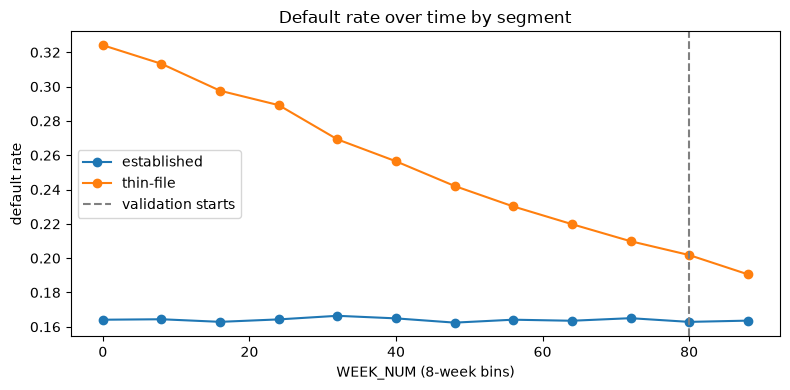

In [6]:
import matplotlib.pyplot as plt

drift = train.groupby([train["WEEK_NUM"] // 8 * 8, "thin_file"])["target"].mean().unstack()
ax = drift.rename(columns={0: "established", 1: "thin-file"}).plot(marker="o", figsize=(8, 4))
ax.axvline(VALID_START_WEEK, color="grey", linestyle="--", label="validation starts")
ax.set(xlabel="WEEK_NUM (8-week bins)", ylabel="default rate", title="Default rate over time by segment")
ax.legend(); plt.tight_layout(); plt.show()

### Which features carry signal?
Univariate ROC-AUC of each numeric feature against `target`, on **training weeks only**. 0.5 means no signal; further from
0.5 means stronger. This is only a quick check. It is not used to build features (that would leak the target).

In [7]:
from sklearn.metrics import roc_auc_score

fit = train[train["WEEK_NUM"] < VALID_START_WEEK]
numeric = fit.select_dtypes("number").drop(columns=["case_id", "target", "WEEK_NUM"])
auc = {c: roc_auc_score(fit["target"], numeric[c].fillna(numeric[c].median())) for c in numeric}
signal = pd.Series(auc).sub(0.5).abs().add(0.5).sort_values(ascending=False)
signal.head(20).round(3).to_frame("univariate AUC")

,univariate AUC
riskassesment_940T,0.696
cb_dpd_mean,0.649
cb_dpd_max,0.622
cb_credamount_mean,0.621
cb_class_count_fe64f125,0.613
numberofqueries_146L,0.606
cb_class_count_54ddc605,0.606
cb_class_count_d8bf6dd7,0.603
cb_overdue_mean,0.599
cb_class_count_6f5666c7,0.593


## 4. Save for notebook 05

In [8]:
train.to_parquet(PROCESSED / "features_train.parquet", index=False)
test.to_parquet(PROCESSED / "features_test.parquet", index=False)
print(f"saved {train.shape[1]} columns:", sorted(p.name for p in PROCESSED.glob("features_*.parquet")))

saved 61 columns: ['features_test.parquet', 'features_train.parquet']
